# Hotel Booking Cancellation Prediction Dataset

## Overview

Dataset ini berisi informasi mengenai reservasi hotel yang dibuat oleh pelanggan, mencakup detail pemesanan, karakteristik tamu, fasilitas yang dipilih, hingga informasi terkait waktu reservasi. Setiap baris data merepresentasikan satu transaksi pemesanan hotel.

Dataset ini dirancang untuk membangun model **hotel booking cancellation prediction**, yaitu memprediksi apakah suatu reservasi hotel akan **dibatalkan** atau **tidak dibatalkan** sebelum tanggal check-in.

Prediksi pembatalan reservasi sangat penting bagi industri perhotelan karena dapat membantu mengurangi kerugian akibat kamar yang kosong, mengoptimalkan strategi overbooking, meningkatkan pengelolaan pendapatan (*revenue management*), serta mendukung pengambilan keputusan operasional.

---

## Objective

Tujuan proyek adalah membangun model machine learning menggunakan algoritma **K-Nearest Neighbors (KNN)** untuk mengklasifikasikan apakah suatu reservasi hotel akan **dibatalkan** (*Canceled*) atau **tidak dibatalkan** (*Not Canceled*) berdasarkan informasi pemesanan dan karakteristik pelanggan.

Target klasifikasi adalah:

* **0** → Reservasi tidak dibatalkan (*Not Canceled*)
* **1** → Reservasi dibatalkan (*Canceled*)

---

## Dataset Structure

| Feature                          | Description                                                              |
| -------------------------------- | ------------------------------------------------------------------------ |
| `booking_id`                     | ID unik setiap reservasi (tidak digunakan sebagai fitur model)           |
| `number_of_adults`               | Jumlah tamu dewasa dalam reservasi                                       |
| `number_of_children`             | Jumlah anak dalam reservasi                                              |
| `number_of_weekend_nights`       | Jumlah malam pada akhir pekan yang dipesan                               |
| `number_of_week_nights`          | Jumlah malam pada hari kerja yang dipesan                                |
| `type_of_meal`                   | Jenis paket makanan yang dipilih                                         |
| `car_parking_space`              | Status permintaan tempat parkir (1 = Ya, 0 = Tidak)                      |
| `room_type`                      | Tipe kamar yang dipesan                                                  |
| `lead_time`                      | Selisih hari antara tanggal pemesanan dan tanggal check-in               |
| `market_segment_type`            | Segmen pasar tempat reservasi berasal (Online, Offline, Corporate, dll.) |
| `repeated`                 | Status apakah pelanggan merupakan tamu yang pernah menginap sebelumnya   |
| `P-C(previous_cancellations)`         | Jumlah reservasi sebelumnya yang pernah dibatalkan oleh pelanggan        |
| `P-not-C(previous_bookings_not_canceled)` | Jumlah reservasi sebelumnya yang berhasil diselesaikan                   |
| `average_price`         | Rata-rata harga kamar per malam                                          |
| `special_requests`               | Jumlah permintaan khusus yang diajukan pelanggan                         |
| `booking_status`                 | Target klasifikasi (1 = Dibatalkan, 0 = Tidak Dibatalkan)                |


## Import Library

In [70]:
import os
import kagglehub
import shutil

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Download Dataset

In [2]:
path = kagglehub.dataset_download("youssefaboelwafa/hotel-booking-cancellation-prediction")

if os.path.exists("./datasets"):
    shutil.rmtree("./datasets")

shutil.copytree(path, "./datasets")
filename = os.listdir("./datasets")
filename

100%|██████████| 470k/470k [00:00<00:00, 1.16MB/s]

Extracting files...


['booking.csv']

## Load Dataset

In [3]:
df = pd.read_csv('./datasets/'+filename[0])
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


## Exploratory Data Analysis

### Hapus Booking_ID dan date of reservation

In [4]:
df = df.drop(columns=['Booking_ID', 'date of reservation'])
df.head(2)

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,booking status
0,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,Not_Canceled
1,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,Not_Canceled


### Ubah booking status ke biner

In [5]:
df['booking status'].unique()

<StringArray>
['Not_Canceled', 'Canceled']
Length: 2, dtype: str

In [6]:
df['booking status'] = df['booking status'].map({'Not_Canceled': 0, 'Canceled': 1})
df.head(2)

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,booking status
0,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,0
1,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,0


### Cek Data Kosong

In [7]:
df.isnull().sum()

number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
booking status              0
dtype: int64

### Cek informasi dan deskripsi data

In [9]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   number of adults          36285 non-null  int64  
 1   number of children        36285 non-null  int64  
 2   number of weekend nights  36285 non-null  int64  
 3   number of week nights     36285 non-null  int64  
 4   type of meal              36285 non-null  str    
 5   car parking space         36285 non-null  int64  
 6   room type                 36285 non-null  str    
 7   lead time                 36285 non-null  int64  
 8   market segment type       36285 non-null  str    
 9   repeated                  36285 non-null  int64  
 10  P-C                       36285 non-null  int64  
 11  P-not-C                   36285 non-null  int64  
 12  average price             36285 non-null  float64
 13  special requests          36285 non-null  int64  
 14  booking status   

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests,booking status
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000
mean,1.844839,0.105360,0.810693,2.204602,0.030977,85.239851,0.025630,0.023343,0.153369,103.421636,0.619733,0.327656
std,0.518813,0.402704,0.870590,1.410946,0.173258,85.938796,0.158032,0.368281,1.753931,35.086469,0.786262,0.469365
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000,1.000000


### Lihat jumlah booking status

In [26]:
df['booking status'].value_counts()

booking status
0    24396
1    11889
Name: count, dtype: int64

### Cek duplikasi data

### Lihat distribusi data

In [15]:
cols = [
    "number of adults", 
    "number of children", 
    "number of weekend nights", 
    "number of week nights", 
    "car parking space",
    "lead time",
    "repeated",
    "P-C",
    "P-not-C",
    "average price",
    "special requests",
    "booking status"
    ]

In [35]:
sns.set_theme(style="whitegrid")

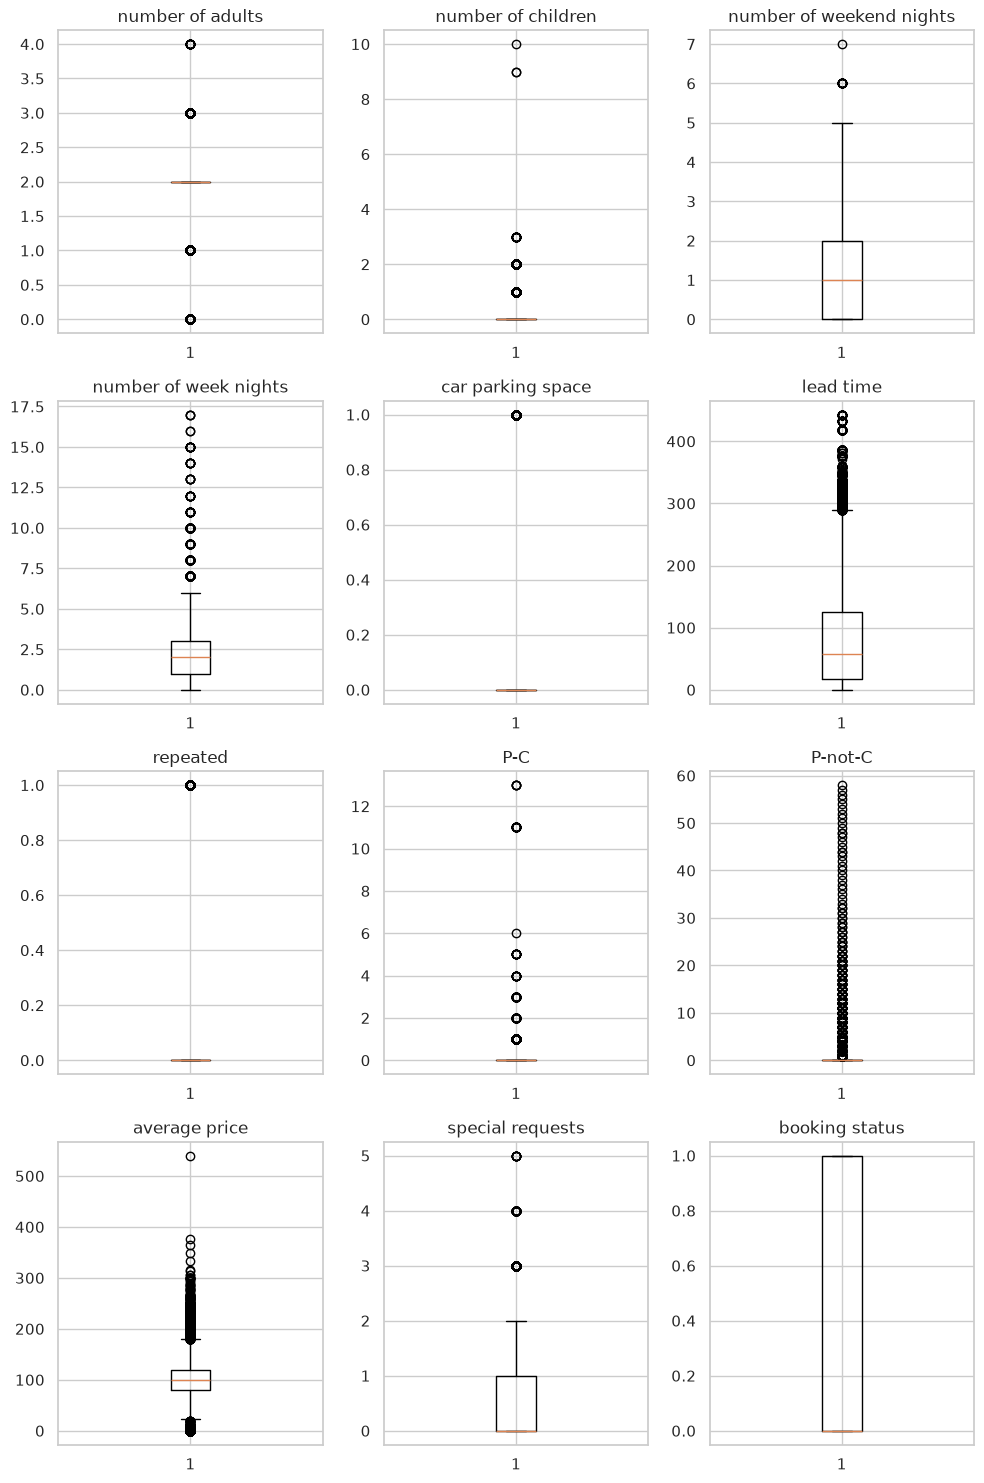

In [38]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10,15))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

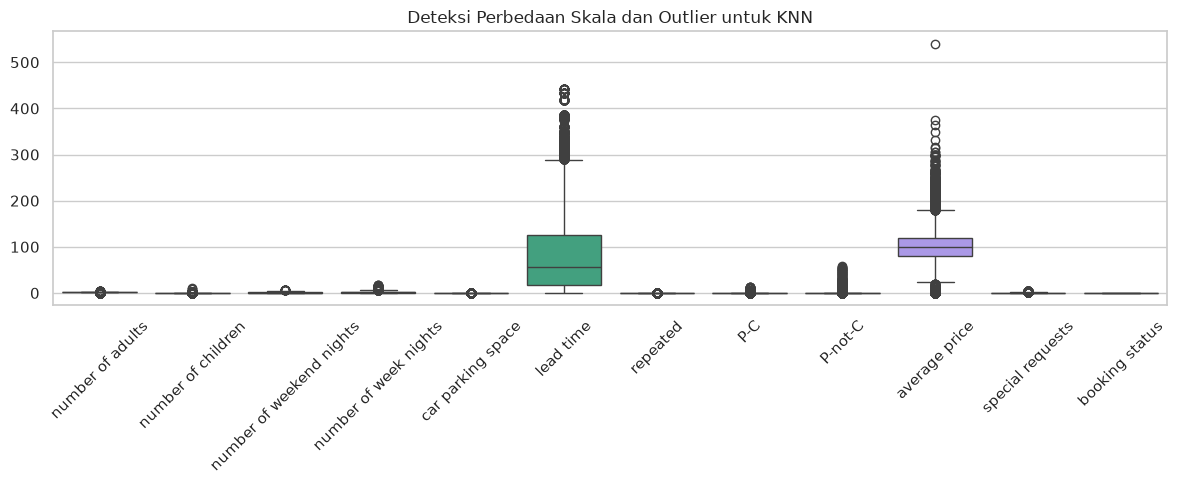

In [39]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[cols])
plt.xticks(rotation=45)
plt.title("Deteksi Perbedaan Skala dan Outlier untuk KNN")
plt.tight_layout()
plt.show()

### Scatter plot

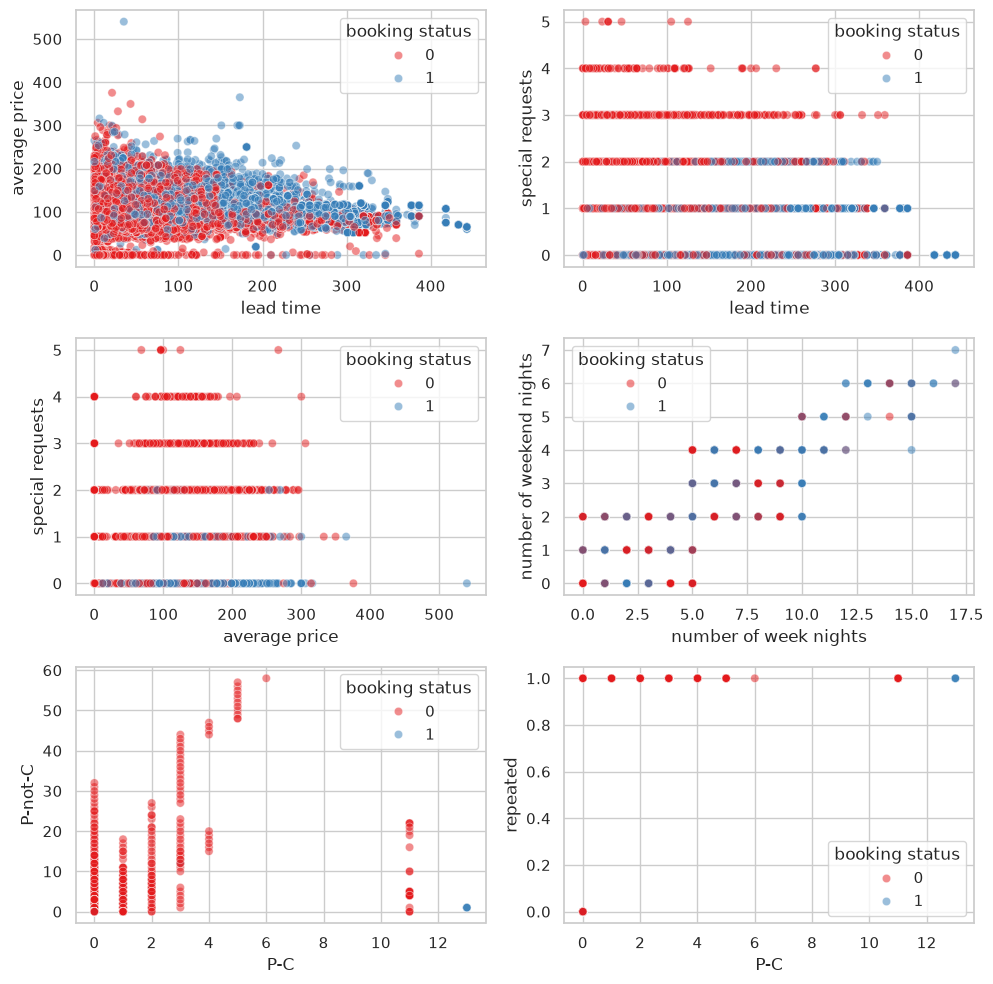

In [60]:
x_cols = ["lead time","lead time", "average price", "number of week nights", "P-C", "P-C"]
y_cols = ["average price", "special requests", "special requests", "number of weekend nights", "P-not-C", "repeated"]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))
axes = axes.flatten()
for i in range(6):
    sns.scatterplot(
        data=df, 
        x=x_cols[i], 
        y=y_cols[i], 
        hue='booking status', 
        alpha=0.5, 
        palette='Set1',
        ax=axes[i]
    )
plt.tight_layout()
plt.show()

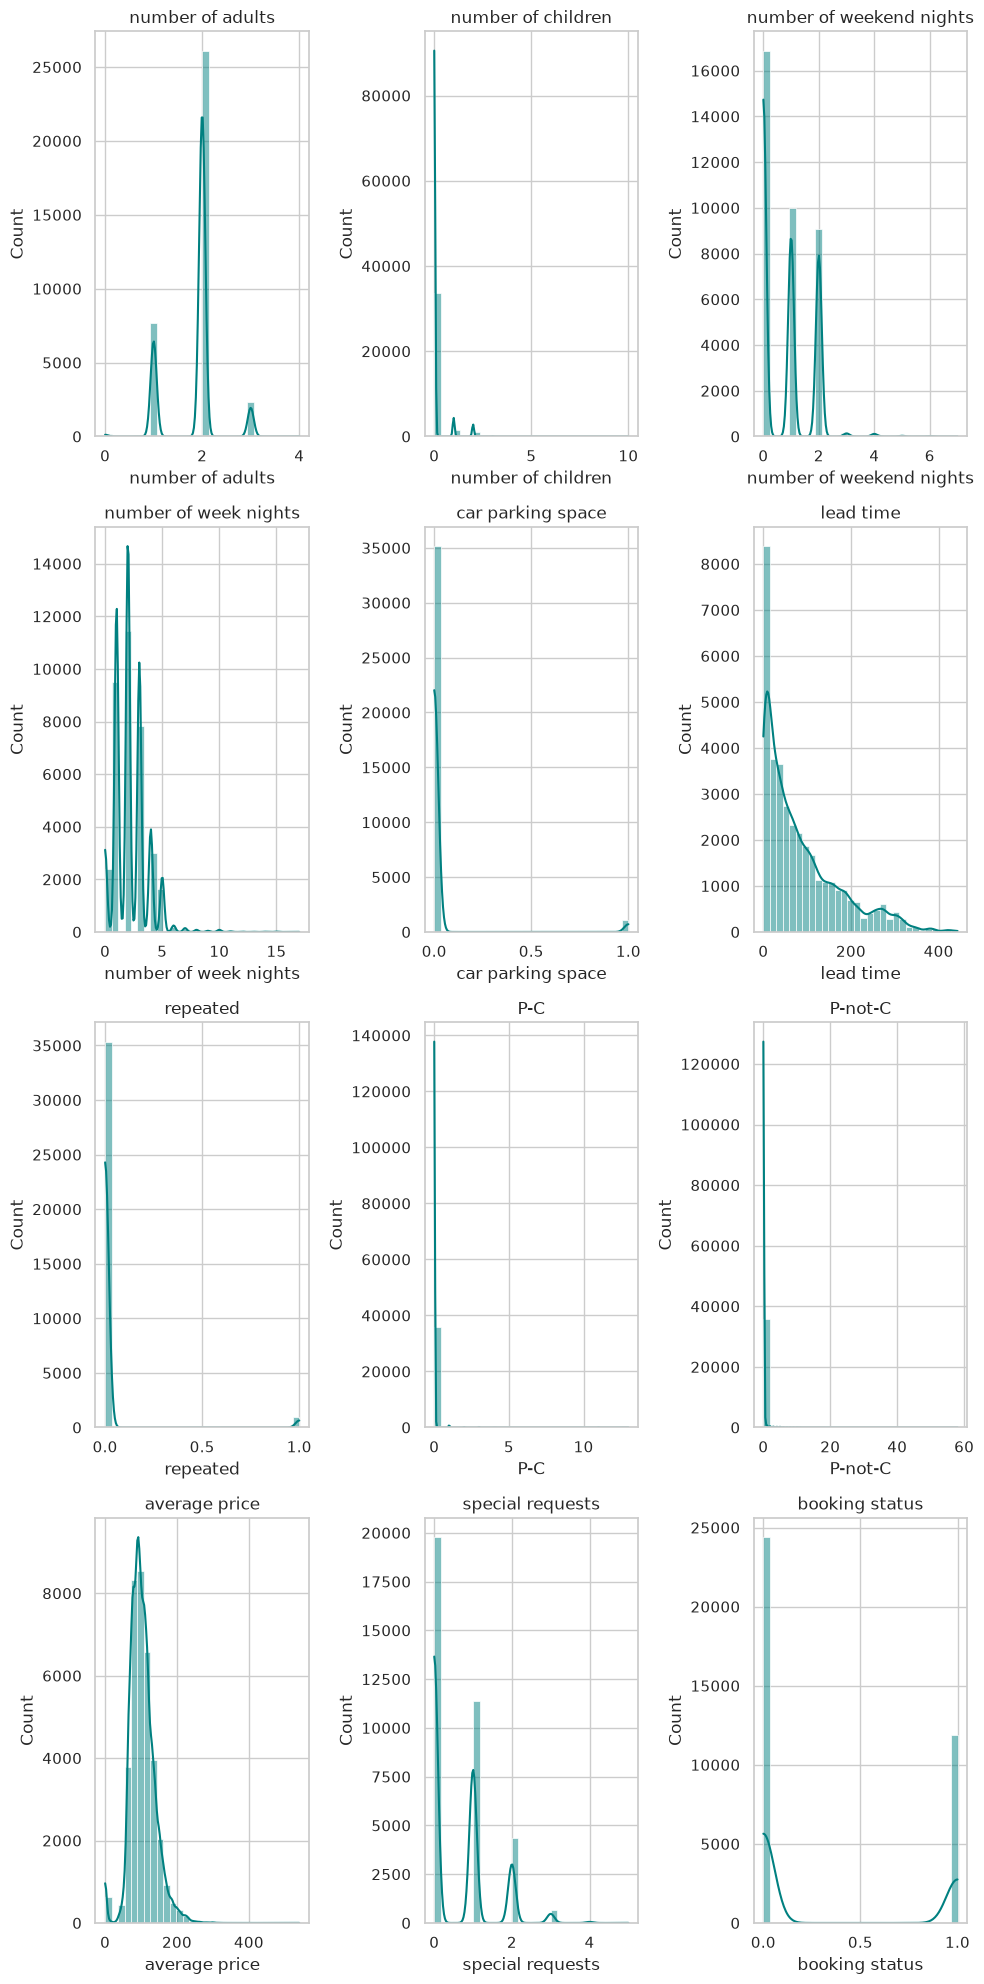

In [46]:
# Melihat bentuk kurva kepadatan dari jarak pemesanan (lead time)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10,20))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(data=df, x=col, kde=True, bins=30, color='teal', ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### Count Plot

In [56]:
df.head(2)

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,booking status
0,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,0
1,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,0


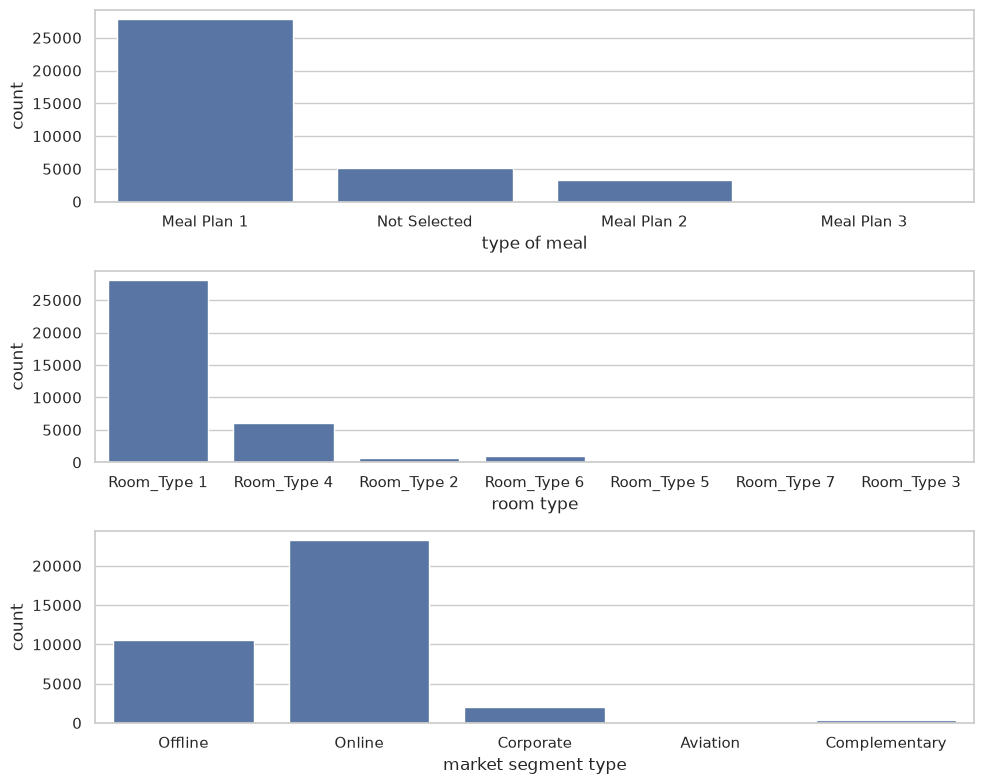

In [57]:
cols = ["type of meal", "room type", "market segment type"]

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, ax=axes[i])
plt.tight_layout()
plt.show()

### Lihat Korelasi

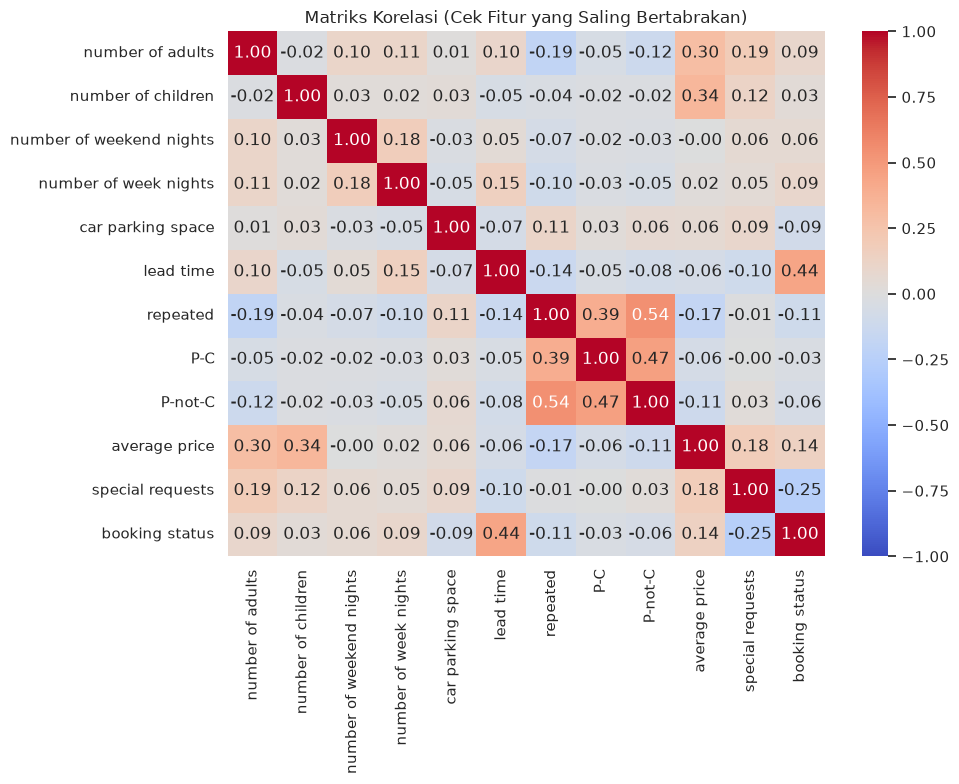

In [48]:
plt.figure(figsize=(10, 8))
# Menghitung korelasi antar fitur angka
korelasi = df[cols].corr()
sns.heatmap(korelasi, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriks Korelasi (Cek Fitur yang Saling Bertabrakan)")
plt.tight_layout()
plt.show()

## Preprocessing

In [ ]:
# pisahkan target dan fitur
X = df.drop(columns=['booking status'])
y = df['booking status']

In [62]:
X.shape

(36285, 14)

In [64]:
kolom_robust = ['lead time', 'average price']
kolom_kategorikal = ['type of meal', 'room type', 'market segment type']
kolom_lainnya = [col for col in X.columns if col not in kolom_robust + kolom_kategorikal]

### Robust Scaler dan OneHotEncoding

In [65]:
preprocessor = ColumnTransformer(
    transformers=[
        ('skala_robust', RobustScaler(), kolom_robust),
        
        ('kategori_encode', OneHotEncoder(drop='first', sparse_output=False), kolom_kategorikal)
    ],
    remainder='passthrough' 
)

## Split dataset

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

### Eksekusi preprocessing

In [67]:
X_train_ready = preprocessor.fit_transform(X_train)

X_test_ready = preprocessor.transform(X_test)

In [68]:
kolom_kategori_baru = preprocessor.named_transformers_['kategori_encode'].get_feature_names_out(kolom_kategorikal)

semua_kolom_baru = kolom_robust + list(kolom_kategori_baru) + kolom_lainnya

X_train_ready_df = pd.DataFrame(X_train_ready, columns=semua_kolom_baru)

In [69]:
X_train_ready_df

,lead time,average price,type of meal_Meal Plan 2,type of meal_Meal Plan 3,type of meal_Not Selected,room type_Room_Type 2,room type_Room_Type 3,room type_Room_Type 4,room type_Room_Type 5,room type_Room_Type 6,...,market segment type_Online,number of adults,number of children,number of weekend nights,number of week nights,car parking space,repeated,P-C,P-not-C,special requests
0,-0.418182,-0.938497,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.590909,0.191091,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.190909,0.148064,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,2.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,1.0
3,0.681818,1.355353,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0
4,-0.372727,-0.618831,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29023,0.281818,-0.064541,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0
29024,-0.381818,-0.163250,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,2.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,1.0
29025,-0.363636,0.032397,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,2.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,1.0
29026,-0.181818,-0.112630,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0


## Baseline Model

In [71]:
knn = KNeighborsClassifier()

## Hyperparameter Tuning

In [72]:
param_grid = {
    # Mencoba nilai K ganjil dari 3 sampai 15 untuk menghindari hasil voting seri
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    
    # 'uniform': semua tetangga punya bobot sama. 
    # 'distance': tetangga yang lebih dekat punya pengaruh lebih besar (bagus untuk data dengan outliers)
    'weights': ['uniform', 'distance'],
    
    # 'euclidean': jarak garis lurus standar
    # 'manhattan': jarak blok (terkadang lebih baik untuk data berdimensi banyak / campuran)
    'metric': ['euclidean', 'manhattan']
}

In [75]:
grid_search = GridSearchCV(
    estimator=knn, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=2,
    verbose=1
)
grid_search.fit(X_train_ready, y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_

In [76]:
print("\n=== HASIL TUNING ===")
print(f"Kombinasi Parameter Terbaik : {grid_search.best_params_}")
print(f"Akurasi Terbaik (CV Score)  : {grid_search.best_score_ * 100:.2f}%")


=== HASIL TUNING ===
Kombinasi Parameter Terbaik : {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
Akurasi Terbaik (CV Score)  : 86.53%


## Evaluasi Model

In [77]:
best_knn_model = grid_search.best_estimator_

# Prediksi ke data test yang belum pernah dilihat model
y_pred = best_knn_model.predict(X_test_ready)

print("\n=== EVALUASI PADA DATA TESTING ===")
print(f"Akurasi Akhir Data Test : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


=== EVALUASI PADA DATA TESTING ===
Akurasi Akhir Data Test : 87.61%

Confusion Matrix:
[[4503  376]
 [ 523 1855]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      4879
           1       0.83      0.78      0.80      2378

    accuracy                           0.88      7257
   macro avg       0.86      0.85      0.86      7257
weighted avg       0.87      0.88      0.88      7257

